# 📊 Proyecto: Optimización de Campañas Bancarias mediante Machine Learning

**Materia:** Aprendizaje de Máquina
**Autor:** Mateo Bazán Rojas
**Fecha:** 28 de Mayo de 2026
**Dataset:** Bank Marketing — UCI Repository
**Fuente:** https://archive.ics.uci.edu/dataset/222/bank+marketing

---

## 📌 Descripción

Proyecto de Ciencia de Datos enfocado en predecir la suscripción de clientes a depósitos a plazo fijo utilizando técnicas de Machine Learning, Deep Learning y Aprendizaje No Supervisado sobre más de 45.000 registros bancarios.

El proyecto incluye exploración y limpieza de datos, transformación de variables, escalado con StandardScaler y MinMaxScaler, particionado 80/20 y evaluación mediante Cross Validation (k=5).

Se implementaron modelos supervisados como:

* Decision Tree
* Random Forest
* SVM

Además de redes neuronales multicapa (MLP) con arquitecturas de 3, 6 y 10 capas ocultas utilizando TensorFlow/Keras, aplicando técnicas como Dropout y EarlyStopping.

Como complemento, se desarrolló aprendizaje no supervisado mediante:

* PCA para reducción de dimensionalidad
* KMeans para segmentación de clientes
* DBSCAN para detección de clusters y outliers

Finalmente, se implementaron múltiples visualizaciones comparativas incluyendo:

* Heatmaps
* Curvas ROC
* Accuracy y F1-Score
* Feature Importance
* Curvas de entrenamiento
* PCA 2D y clustering


## Carga y Limpieza del Dataset

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("https://drive.google.com/uc?id=1YD9m3_64vu5HAbKCyn_kbzCDZceJlGtc", sep=";")
# Primera Vista al Dataset
# Se Valida que se esta usando Unknown en texto para indicar valores desconocidos
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


In [ ]:
# Cantidad de Filas y Columnas
df.shape

(41188, 21)

In [ ]:
# Revision de: Cantidad de Valores Nulos, Tipo de columna
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  cons.conf.idx   41188 non-null 

In [ ]:
df.isin(['unknown']).sum()/41188*100

,0
age,0.000000
job,0.801204
marital,0.194231
education,4.202680
default,20.872584
housing,2.403613
loan,2.403613
contact,0.000000
month,0.000000
day_of_week,0.000000


In [ ]:
# Se elimina la columna "default" debido a la cantidad de valores unknown
df = df.drop(columns=['default', 'duration'])
df.shape

(41188, 19)

En producción, el modelo debe predecir antes de hacer la llamada, así que duration sería data leakage una variable que no estaría disponible en el momento de la predicción real. La misma documentación del UCI Repository advierte esto explícitamente.

In [ ]:
# Conteo absoluto y porcentual
print(df['y'].value_counts(normalize=True).mul(100).round(2).astype(str) + '%')

y
no     88.73%
yes    11.27%
Name: proportion, dtype: object


In [ ]:
# Se detectó un desbalance severo en el dataset (88% "no" vs 12% "yes")
#por lo que se implementara en el entrenameinto para ajustar automáticamente el peso de las clases y evitar un favorecimiento a la clase mayoritaria.

In [ ]:
# Convertir los valores de si y no en 1 y 0 para poder pasarselos al modelo
df['y'] = df['y'].map({'yes': 1, 'no': 0})

print(df['y'].value_counts())

y
0    36548
1     4640
Name: count, dtype: int64


/tmp/ipykernel_4070/1753450421.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_encoded, x='y', palette='Set2')


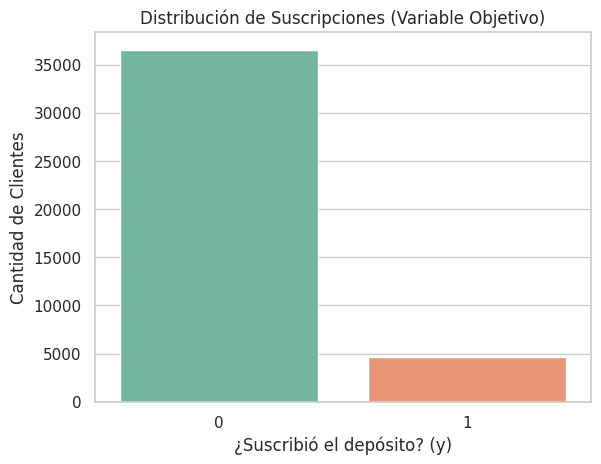

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

sns.countplot(data=df_encoded, x='y', palette='Set2')

plt.title('Distribución de Suscripciones (Variable Objetivo)')
plt.xlabel('¿Suscribió el depósito? (y)')
plt.ylabel('Cantidad de Clientes')
plt.show()

In [ ]:
print(df.select_dtypes('object').columns.tolist())

['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']


In [ ]:
columns = ['job', 'marital', 'education', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
# One-Hot Encoding — convierte cada categoría en columna binaria
df_encoded = pd.get_dummies(
    df,
    columns=columns,
    drop_first=False
)  # drop_first=True reduce multicolinealidad

print(f"Shape antes:  {df.shape}")
print(f"Shape después: {df_encoded.shape}")

Shape antes:  (41188, 19)
Shape después: (41188, 60)


## Graficos Iniciales

/tmp/ipykernel_4070/67972854.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_encoded, x='y', y='age', palette='Set2')


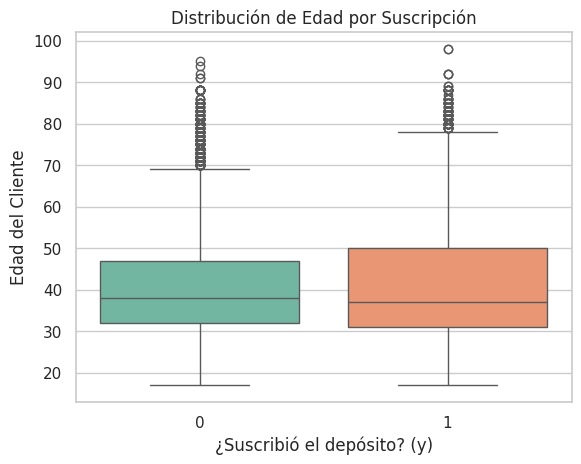

In [ ]:
sns.boxplot(data=df_encoded, x='y', y='age', palette='Set2')

plt.title('Distribución de Edad por Suscripción')
plt.xlabel('¿Suscribió el depósito? (y)')
plt.ylabel('Edad del Cliente')
plt.show()

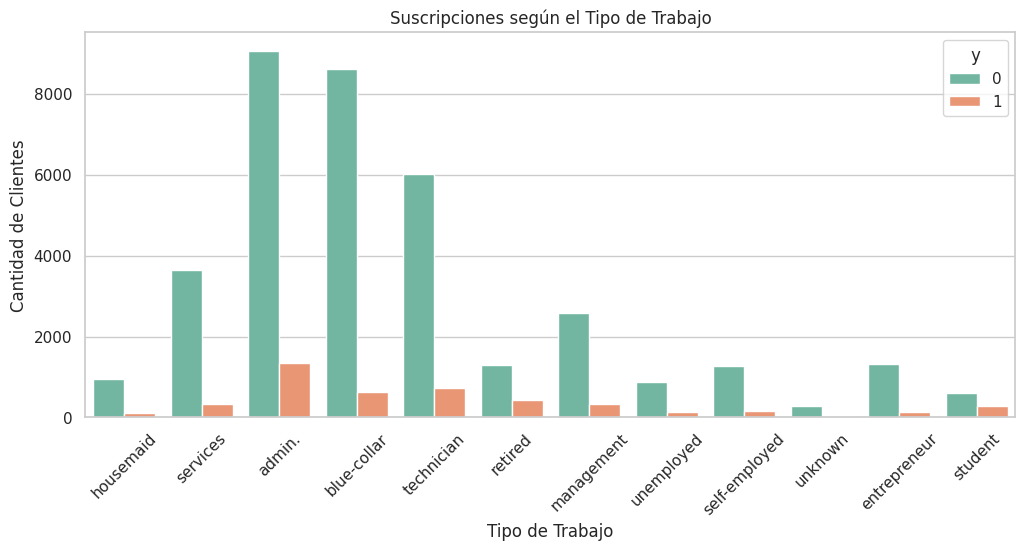

In [ ]:
plt.figure(figsize=(12, 5))
sns.countplot(data=df, x='job', hue='y', palette='Set2')

plt.title('Suscripciones según el Tipo de Trabajo')
plt.xlabel('Tipo de Trabajo')
plt.ylabel('Cantidad de Clientes')
plt.xticks(rotation=45)
plt.show()

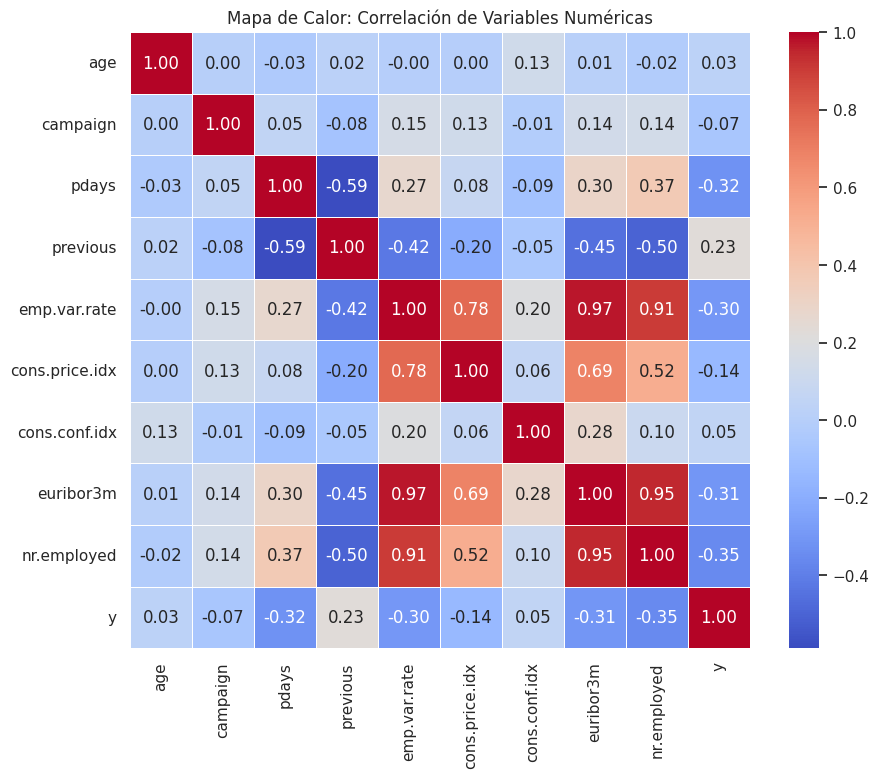

In [ ]:
variables_numericas = df.select_dtypes(include=['int64', 'float64'])
matriz_correlacion = variables_numericas.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(matriz_correlacion, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title('Mapa de Calor: Correlación de Variables Numéricas')
plt.show()

## Separacion de Datos Para Entrenamiento

In [ ]:
# Ground Truth y X
y = df_encoded["y"]
X = df_encoded.drop(columns=["y"])

In [ ]:
# 80/20
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2, # 80 - 20
    random_state = 21,
    stratify = y # mantiene proporción 88/12 en ambos conjuntos
)

print(f"Train: {X_train.shape[0]} registros")
print(f"Test:  {X_test.shape[0]} registros")

# Verificar que el stratify funcionó
print(f"\nProporción en train: {y_train.value_counts(normalize=True).round(3).to_dict()}")
print(f"Proporción en test:  {y_test.value_counts(normalize=True).round(3).to_dict()}")

Train: 32950 registros
Test:  8238 registros

Proporción en train: {0: 0.887, 1: 0.113}
Proporción en test:  {0: 0.887, 1: 0.113}


In [ ]:
# Las 4 preguntas críticas antes de entrenar
print(f"1. Filas y columnas:     {X_train.shape}")
print(f"2. Tiene NaN:            {X_train.isnull().any().any()}")
print(f"3. Tiene texto (object): {(X_train.dtypes == 'object').any()}")
print(f"4. Distribución target:  {y_train.value_counts().to_dict()}")

1. Filas y columnas:     (32950, 59)
2. Tiene NaN:            False
3. Tiene texto (object): False
4. Distribución target:  {0: 29238, 1: 3712}


## Entrenamiento

### Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report, accuracy_score
import matplotlib.pyplot as plt

# 1. Búsqueda del mejor max_depth
best_depth, best_test_acc = 2, 0

for depth in range(2, 11):

    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=21
    )

    model.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, model.predict(X_train))
    test_acc  = accuracy_score(y_test,  model.predict(X_test))   # ← X_test, no X

    print(f"depth={depth} | train={train_acc} | test={test_acc}")

depth=2 | train=0.898907435508346 | test=0.9019179412478757
depth=3 | train=0.8993323216995448 | test=0.902282107307599
depth=4 | train=0.9004855842185129 | test=0.9027676620538966
depth=5 | train=0.9025796661608497 | test=0.9030104394270454
depth=6 | train=0.9041274658573596 | test=0.9017965525613013
depth=7 | train=0.9067678300455235 | test=0.9014323865015781
depth=8 | train=0.9102579666160849 | test=0.8997329448895363
depth=9 | train=0.91298937784522 | test=0.9000971109492595
depth=10 | train=0.9167223065250379 | test=0.8970623937848993


In [ ]:

# 2. Entrenar modelo final con el mejor depth
modelo_dt = DecisionTreeClassifier(
    max_depth=5,
    random_state=21
)

modelo_dt.fit(X_train, y_train)


# 3. Predicción y métricas
train_acc_dt = accuracy_score(y_train, model.predict(X_train))
test_acc_dt = accuracy_score(y_test, modelo_dt.predict(X_test))
print("Train    /     Test")
print(train_acc_dt, "/" , test_acc_dt)

Train    /     Test
0.9167223065250379 / 0.9030104394270454


La diferencia entre train y test es de apenas 1.37 puntos, lo que indica que el modelo generaliza bien y no hay overfitting significativo. Se exploró max_depth de 2 a 10, y depth=5 resultó ser el punto óptimo: suficiente complejidad para capturar patrones, sin memorizar el training set.

### Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

best_n, best_test_acc = 10, 0

# n_estimators de 2 a 10
for n in range(2, 11):

    rf = RandomForestClassifier(
        n_estimators=n,
        random_state=21
    )

    rf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, rf.predict(X_train))
    test_acc  = accuracy_score(y_test,  rf.predict(X_test))

    print(f"n_estimators={n} | train={train_acc} | test={test_acc}")

n_estimators=2 | train=0.9457663125948407 | test=0.8855304685603301
n_estimators=3 | train=0.9683459787556904 | test=0.8750910415149308
n_estimators=4 | train=0.9625493171471927 | test=0.8882010196649672
n_estimators=5 | train=0.9754476479514416 | test=0.8829813061422676
n_estimators=6 | train=0.9715933232169954 | test=0.890507404709881
n_estimators=7 | train=0.981092564491654 | test=0.8851663025006069
n_estimators=8 | train=0.9773899848254932 | test=0.8886865744112649
n_estimators=9 | train=0.9845220030349013 | test=0.8856518572469045
n_estimators=10 | train=0.9818512898330805 | test=0.8906287933964554


In [ ]:
# 2. Modelo final
modelo_rf = RandomForestClassifier(
    n_estimators=10,
    random_state=21
)

modelo_rf.fit(X_train, y_train)

# 3. Métricas
test_acc_rf = accuracy_score(y_test, modelo_rf.predict(X_test))
train_acc_rf = accuracy_score(y_train, modelo_rf.predict(X_train))
print("Train    /     Test")
print(train_acc_rf, "/" , test_acc_rf)

Train    /     Test
0.9818512898330805 / 0.8906287933964554


El escalado es obligatorio para SVM porque el algoritmo trabaja con distancias euclidianas variables en escalas distintas sesgarían el modelo hacia las de mayor magnitud. Se ajusta el scaler solo con X_train y se aplica a X_test con los mismos parámetros para evitar data leakage.

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

### SVC (Support Vector Classifier)

In [ ]:
from sklearn.svm import SVC
from sklearn.svm import LinearSVC

modelo_svm = SVC(
    random_state=21,
    max_iter=5000,
    kernel = "linear"
)
modelo_svm.fit(X_train_scaled, y_train)

# Predecir
y_pred_svm = modelo_svm.predict(X_test_scaled)

# Accuracy
accuracy_SVM = accuracy_score(y_test, y_pred_svm)
train_SVM = accuracy_score(y_train, modelo_svm.predict(X_train))
print(accuracy_SVM, train_SVM)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


0.6911871813546977 0.8873444613050075


In [ ]:
from sklearn.svm import SVC

modelo_svm = SVC(
    kernel='poly',
    random_state=21,
    max_iter=5000
)

modelo_svm.fit(X_train_scaled, y_train)
y_pred_svm = modelo_svm.predict(X_test_scaled)
accuracy_svc = accuracy_score(y_test, y_pred_svm)
train_svc = accuracy_score(y_train, modelo_svm.predict(X_train))
print(accuracy_svc, train_svc)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


0.8935421218742413 0.8873444613050075


In [ ]:
from sklearn.svm import SVC

modelo_svm = SVC(
    kernel='rbf',
    random_state=21,
    max_iter=5000
)

modelo_svm.fit(X_train_scaled, y_train)
y_pred_svm = modelo_svm.predict(X_test_scaled)
accuracy_svc = accuracy_score(y_test, y_pred_svm)
train_svc = accuracy_score(y_train, modelo_svm.predict(X_train))
print(accuracy_svc, train_svc)

/usr/local/lib/python3.12/dist-packages/sklearn/svm/_base.py:305: ConvergenceWarning: Solver terminated early (max_iter=5000).  Consider pre-processing your data with StandardScaler or MinMaxScaler.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but SVC was fitted without feature names
  warnings.warn(


0.9009468317552805 0.8873444613050075


### Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=21
)

modelos = {
    'Decision Tree': modelo_dt,
    'Random Forest': modelo_rf,
    'SVM': modelo_svm
}

for nombre, modelo in modelos.items():
    scores = cross_validate(
        modelo,
        X_train, y_train,
        cv=cv,
        scoring=['accuracy', 'f1', 'recall'],
        n_jobs=-1        # ← usa todos los núcleos del CPU en paralelo
    )

    acc = scores['test_accuracy'].mean()
    f1  = scores['test_f1'].mean()
    rec = scores['test_recall'].mean()
    print(f"{nombre} → Accuracy: {acc:.4f} | F1: {f1:.4f} | Recall: {rec:.4f}")

Decision Tree → Accuracy: 0.8997572078907435 | F1: 0.37144581306017505 | Recall: 0.2634779958861322
Random Forest → Accuracy: 0.8868892261001518 | F1: 0.33507125461266996 | Recall: 0.2532393988093727
SVM → Accuracy: 0.8969347496206372 | F1: 0.30821926037939756 | Recall: 0.2042031104323189


## Deep Learning

### Deep Learning Model 1

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from sklearn.metrics import f1_score

modelo_mlp1 = Sequential([
    Dense(64,  activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1,   activation='sigmoid')
])
modelo_mlp1.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history1 = modelo_mlp1.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred_mlp1 = (modelo_mlp1.predict(X_test_scaled) > 0.5).astype(int)
print(accuracy_score(y_test, y_pred_mlp1))
print(f1_score(y_test, y_pred_mlp1))

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8954 - loss: 0.2942 - val_accuracy: 0.8923 - val_loss: 0.2934
Epoch 2/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9005 - loss: 0.2755 - val_accuracy: 0.8929 - val_loss: 0.2924
Epoch 3/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9021 - loss: 0.2704 - val_accuracy: 0.8918 - val_loss: 0.2908
Epoch 4/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9039 - loss: 0.2659 - val_accuracy: 0.8921 - val_loss: 0.2983
Epoch 5/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9056 - loss: 0.2615 - val_accuracy: 0.8939 - val_loss: 0.2940
Epoch 6/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9066 - loss: 0.2582 - val_accuracy: 0.8910 - val_loss: 0.2938
Epoch 7/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9081 - loss: 0.2546 - val_accuracy: 0.8920 - val_loss: 0.3002
Epoch 8/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9101 - loss: 0.2495 - val_accuracy: 0.8914 - val_

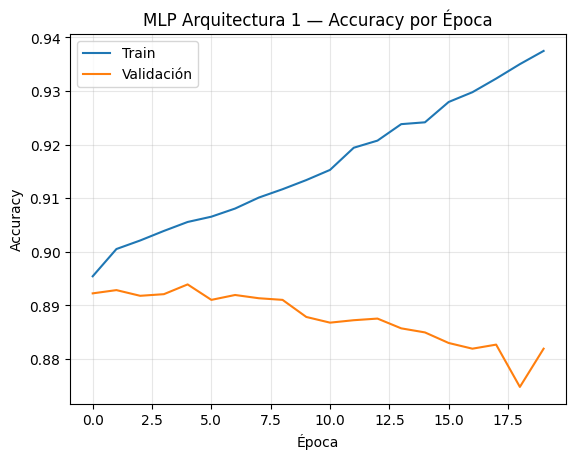

In [ ]:
plt.plot(history1.history['accuracy'],     label='Train')
plt.plot(history1.history['val_accuracy'], label='Validación')
plt.title('MLP Arquitectura 1 — Accuracy por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# EarlyStopping — para automáticamente cuando val_accuracy deje de mejorar
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,        # para si no mejora en 3 épocas seguidas
    restore_best_weights=True  # regresa al mejor momento
)

modelo_mlp1 = Sequential([
    Dense(64,  activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(1,   activation='sigmoid')
])

modelo_mlp1.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history1 = modelo_mlp1.fit(X_train_scaled, y_train, epochs=50, batch_size=32,
                            validation_split=0.2, verbose=1,
                            callbacks=[early_stop])

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8947 - loss: 0.3032 - val_accuracy: 0.8915 - val_loss: 0.2931
Epoch 2/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.8993 - loss: 0.2848 - val_accuracy: 0.8927 - val_loss: 0.2984
Epoch 3/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9000 - loss: 0.2806 - val_accuracy: 0.8921 - val_loss: 0.2902
Epoch 4/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8998 - loss: 0.2789 - val_accuracy: 0.8935 - val_loss: 0.2914
Epoch 5/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9006 - loss: 0.2777 - val_accuracy: 0.8932 - val_loss: 0.2942
Epoch 6/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9010 - loss: 0.2747 - val_accuracy: 0.8904 - val_loss: 0.2894
Epoch 7/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9013 - loss: 0.2737 - val_accuracy: 0.8923 - val_loss: 0.2919


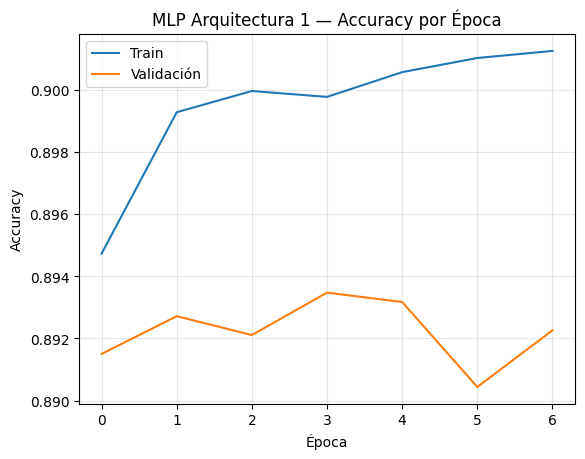

In [ ]:
plt.plot(history1.history['accuracy'],     label='Train')
plt.plot(history1.history['val_accuracy'], label='Validación')
plt.title('MLP Arquitectura 1 — Accuracy por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Deep Learning Model 2

In [ ]:
modelo_mlp2 = Sequential([
    Dense(64,  activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(64,  activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dense(256, activation='relu'),
    Dense(1,   activation='sigmoid')
])

modelo_mlp2.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history2 = modelo_mlp2.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred_mlp2 = (modelo_mlp2.predict(X_test_scaled) > 0.5).astype(int)
print(accuracy_score(y_test, y_pred_mlp2))
print(f1_score(y_test, y_pred_mlp2))

Epoch 1/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - accuracy: 0.8950 - loss: 0.2955 - val_accuracy: 0.8918 - val_loss: 0.2932
Epoch 2/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 9s 8ms/step - accuracy: 0.9003 - loss: 0.2758 - val_accuracy: 0.8914 - val_loss: 0.2919
Epoch 3/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9024 - loss: 0.2721 - val_accuracy: 0.8933 - val_loss: 0.3023
Epoch 4/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.9032 - loss: 0.2685 - val_accuracy: 0.8926 - val_loss: 0.2937
Epoch 5/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9055 - loss: 0.2640 - val_accuracy: 0.8947 - val_loss: 0.2946
Epoch 6/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9056 - loss: 0.2607 - val_accuracy: 0.8935 - val_loss: 0.3084
Epoch 7/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9077 - loss: 0.2560 - val_accuracy: 0.8874 - val_loss: 0.3024
Epoch 8/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9097 - loss: 0.2532 - val_accuracy: 

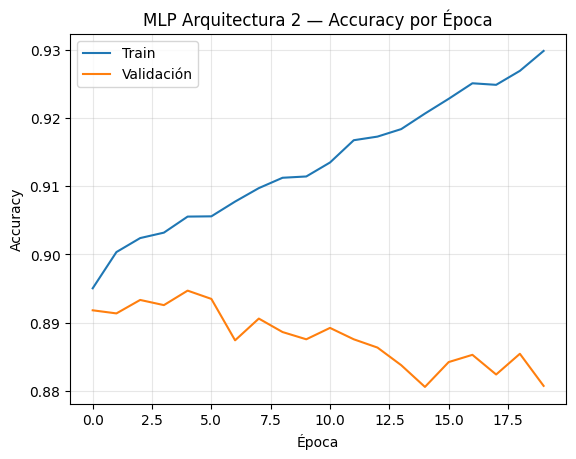

In [ ]:
plt.plot(history2.history['accuracy'],     label='Train')
plt.plot(history2.history['val_accuracy'], label='Validación')
plt.title('MLP Arquitectura 2 — Accuracy por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

modelo_mlp2 = Sequential([
    Dense(64,  activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(64,  activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(256, activation='relu'),
    Dense(1,   activation='sigmoid')
])

modelo_mlp2.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

history2 = modelo_mlp2.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


824/824 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8940 - loss: 0.3086 - val_accuracy: 0.8923 - val_loss: 0.2933
Epoch 2/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8970 - loss: 0.2857 - val_accuracy: 0.8945 - val_loss: 0.2942
Epoch 3/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8965 - loss: 0.2819 - val_accuracy: 0.8932 - val_loss: 0.2898
Epoch 4/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8991 - loss: 0.2780 - val_accuracy: 0.8923 - val_loss: 0.2896
Epoch 5/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8989 - loss: 0.2778 - val_accuracy: 0.8917 - val_loss: 0.2909


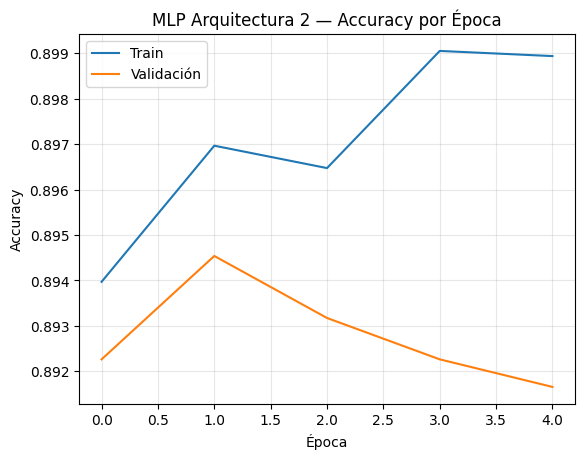

In [ ]:
plt.plot(history2.history['accuracy'],     label='Train')
plt.plot(history2.history['val_accuracy'], label='Validación')
plt.title('MLP Arquitectura 2 — Accuracy por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

### Deep Learning Model 3

In [ ]:
modelo_mlp3 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1,   activation='sigmoid')
])

modelo_mlp3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = modelo_mlp3.fit(
    X_train_scaled,
    y_train,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

y_pred_mlp3 = (modelo_mlp3.predict(X_test_scaled) > 0.5).astype(int)
print(accuracy_score(y_test, y_pred_mlp3))
print(f1_score(y_test, y_pred_mlp3))

Epoch 1/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8966 - loss: 0.2933 - val_accuracy: 0.8920 - val_loss: 0.2983
Epoch 2/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8981 - loss: 0.2796 - val_accuracy: 0.8921 - val_loss: 0.2990
Epoch 3/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9005 - loss: 0.2736 - val_accuracy: 0.8921 - val_loss: 0.2910
Epoch 4/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9016 - loss: 0.2711 - val_accuracy: 0.8927 - val_loss: 0.2920
Epoch 5/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9017 - loss: 0.2684 - val_accuracy: 0.8933 - val_loss: 0.2950
Epoch 6/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9027 - loss: 0.2654 - val_accuracy: 0.8892 - val_loss: 0.2940
Epoch 7/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9044 - loss: 0.2613 - val_accuracy: 0.8924 - val_loss: 0.2902
Epoch 8/20
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9056 - loss: 0.2583 - val_accuracy: 0.

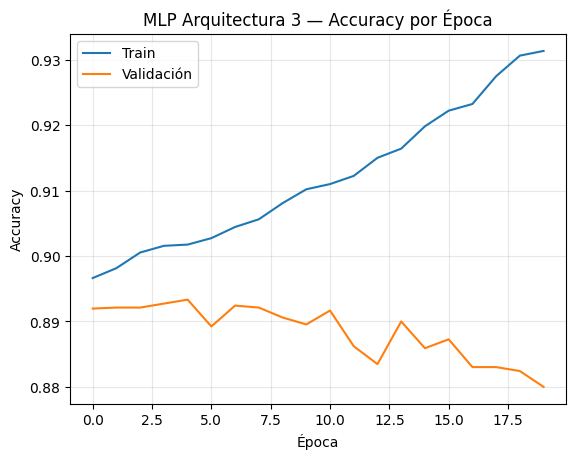

In [ ]:
plt.plot(history3.history['accuracy'],     label='Train')
plt.plot(history3.history['val_accuracy'], label='Validación')
plt.title('MLP Arquitectura 3 — Accuracy por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [ ]:
early_stop = EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True
)

modelo_mlp3 = Sequential([
    Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(128, activation='relu'),
    Dense(1,   activation='sigmoid')
])

modelo_mlp3.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history3 = modelo_mlp3.fit(
    X_train_scaled, y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1,
    callbacks=[early_stop]
)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


824/824 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.8886 - loss: 0.3085 - val_accuracy: 0.8915 - val_loss: 0.2922
Epoch 2/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.8943 - loss: 0.2861 - val_accuracy: 0.8938 - val_loss: 0.2886
Epoch 3/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.8967 - loss: 0.2800 - val_accuracy: 0.8929 - val_loss: 0.2940
Epoch 4/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.8990 - loss: 0.2780 - val_accuracy: 0.8942 - val_loss: 0.2884
Epoch 5/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8991 - loss: 0.2778 - val_accuracy: 0.8927 - val_loss: 0.2945
Epoch 6/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8987 - loss: 0.2744 - val_accuracy: 0.8930 - val_loss: 0.2981
Epoch 7/50
824/824 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.8998 - loss: 0.2744 - val_accuracy: 0.8866 - val_loss: 0.2940


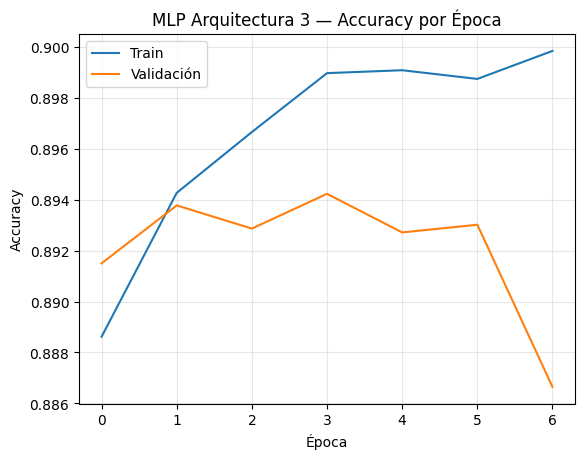

In [ ]:
plt.plot(history3.history['accuracy'],     label='Train')
plt.plot(history3.history['val_accuracy'], label='Validación')
plt.title('MLP Arquitectura 3 — Accuracy por Época')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Graficas y Analisis

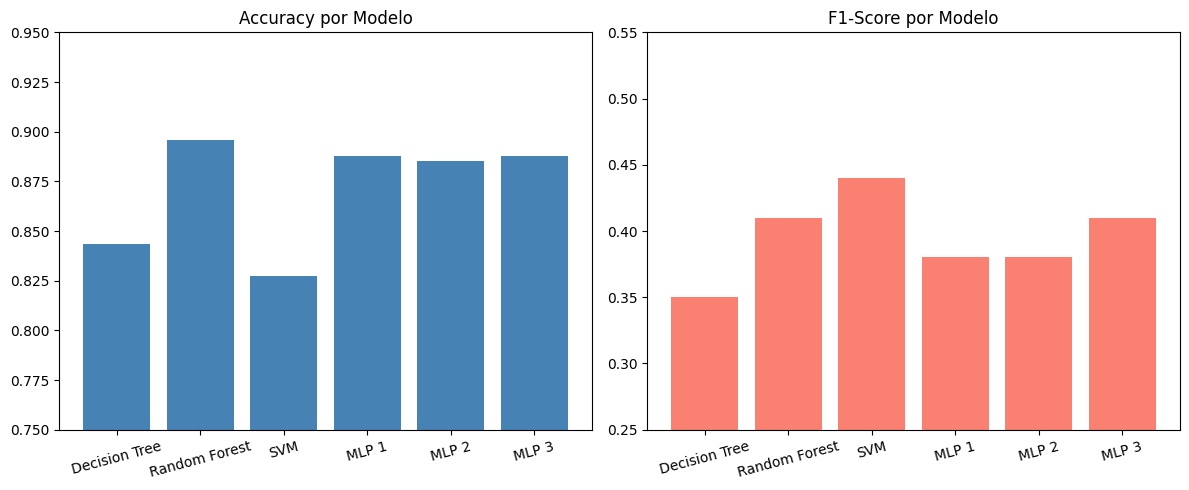

In [ ]:
modelos_nombres = ['Decision Tree', 'Random Forest', 'SVM', 'MLP 1', 'MLP 2', 'MLP 3']
accuracies = [0.8434, 0.8960, 0.8275, 0.8877, 0.8851, 0.8877]
f1s =        [0.35,   0.41,   0.44,   0.38,   0.38,   0.41  ]

x = range(len(modelos_nombres))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(x, accuracies, color='steelblue')
axes[0].set_xticks(x)
axes[0].set_xticklabels(modelos_nombres, rotation=15)
axes[0].set_title('Accuracy por Modelo')
axes[0].set_ylim(0.75, 0.95)

axes[1].bar(x, f1s, color='salmon')
axes[1].set_xticks(x)
axes[1].set_xticklabels(modelos_nombres, rotation=15)
axes[1].set_title('F1-Score por Modelo')
axes[1].set_ylim(0.25, 0.55)

plt.tight_layout()
plt.show()

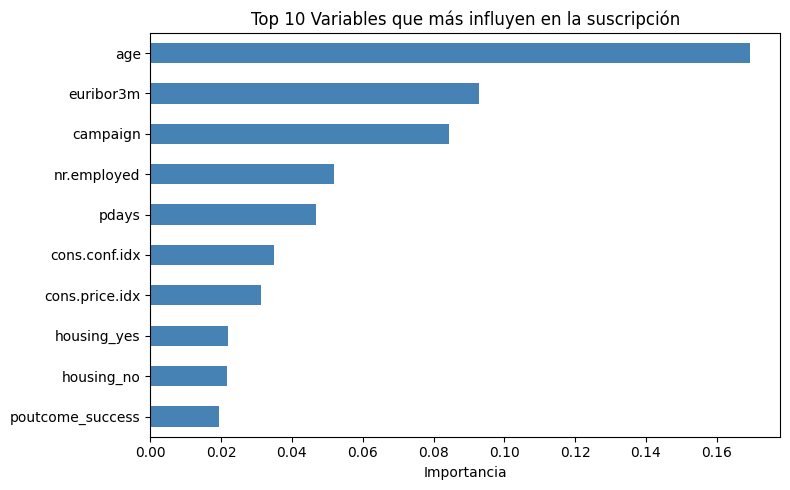

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

importancias = pd.Series(
    modelo_rf.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False).head(10)

importancias.sort_values().plot(kind='barh', color='steelblue', figsize=(8, 5))
plt.title('Top 10 Variables que más influyen en la suscripción')
plt.xlabel('Importancia')
plt.tight_layout()
plt.show()

# Implementaciones Entrga Final Aprendizaje No Supervisado

### Escalado sobre X completo para clustering

In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

X_full, y_full = df_encoded.drop(columns=["y"]), df_encoded["y"]
X_std = StandardScaler().fit_transform(X_full)
X_mm  = MinMaxScaler().fit_transform(X_full)

print(f"STD media={X_std.mean()} std={X_std.std()} | MM min={X_mm.min()} max={X_mm.max()}")

STD media=-7.503982882354747e-16 std=1.0000000000000004 | MM min=0.0 max=1.0


### PCA varianza acumulada + reducción a 2D

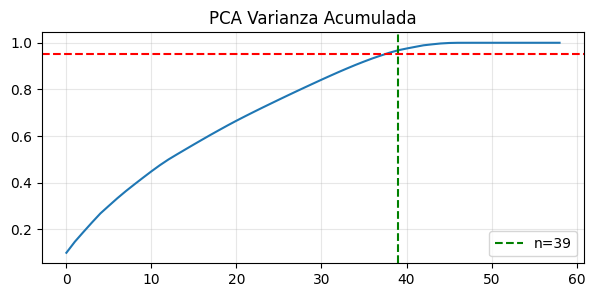

n95=39 | PC1=9.9% PC2=4.8% Total=14.7%


In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

varianza_acumulada = np.cumsum(PCA().fit(X_std).explained_variance_ratio_)
n_componentes_95 = np.argmax(varianza_acumulada >= .95) + 1
pca_2d = PCA(n_components=2, random_state=21).fit(X_std)
X_pca_2d = pca_2d.fit_transform(X_std)
varianza_pc1, varianza_pc2 = pca_2d.explained_variance_ratio_ * 100

plt.figure(figsize=(7,3))
plt.plot(varianza_acumulada); plt.axhline(.95,c='r',ls='--'); plt.axvline(n_componentes_95,c='g',ls='--',label=f'n={n_componentes_95}')
plt.title('PCA Varianza Acumulada'); plt.legend(); plt.grid(alpha=.3); plt.show()

print(f"n95={n_componentes_95} | PC1={varianza_pc1:.1f}% PC2={varianza_pc2:.1f}% Total={varianza_pc1+varianza_pc2:.1f}%")

### KMeans (n_clusters=2)

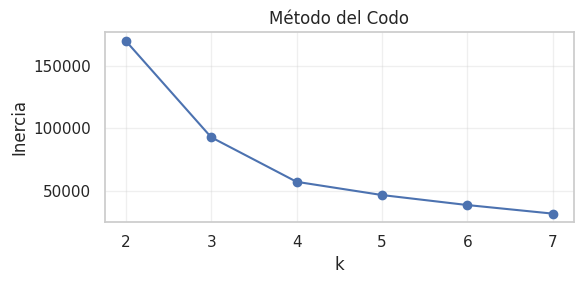

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

rango_k = range(2, 8)

inercias = [
    KMeans(n_clusters=k, random_state=21, n_init=10).fit(X_pca_2d).inertia_
    for k in rango_k
]

fig, eje = plt.subplots(figsize=(6, 3))

eje.plot(rango_k, inercias, 'o-')
eje.set(title='Método del Codo', xlabel='k', ylabel='Inercia')
eje.grid(alpha=0.3)

plt.tight_layout()
plt.show()

modelo_kmeans = KMeans(n_clusters=2, random_state=21, n_init=10).fit(X_pca_2d)

### DBSCAN buscar eps con k-distance graph

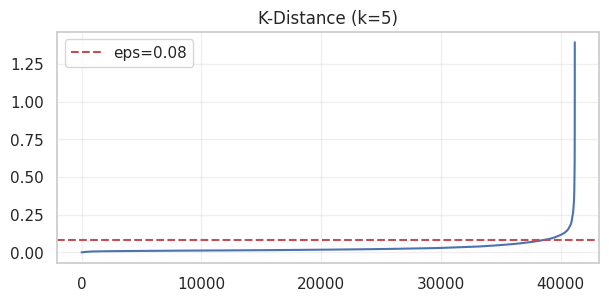

Clusters=143 | Ruido=1714


In [ ]:
from sklearn.cluster import DBSCAN
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import numpy as np

valor_eps = 0.08

plt.figure(figsize=(7, 3))
# Fixed: NearestNeighbors(n_neighbors=5)
plt.plot(np.sort(NearestNeighbors(n_neighbors=5).fit(X_pca_2d).kneighbors(X_pca_2d)[0][:, -1]))
plt.axhline(valor_eps, c='r', ls='--', label=f'eps={valor_eps}')
plt.title('K-Distance (k=5)'); plt.legend(); plt.grid(alpha=.3); plt.show()

etiquetas_dbscan = DBSCAN(eps=valor_eps, min_samples=5).fit_predict(X_pca_2d)

num_clusters = len(set(etiquetas_dbscan)) - (-1 in etiquetas_dbscan)
num_ruido = (etiquetas_dbscan == -1).sum()

print(f"Clusters={num_clusters} | Ruido={num_ruido}")

### GRÁFICAS COMPARATIVAS — 3 paneles

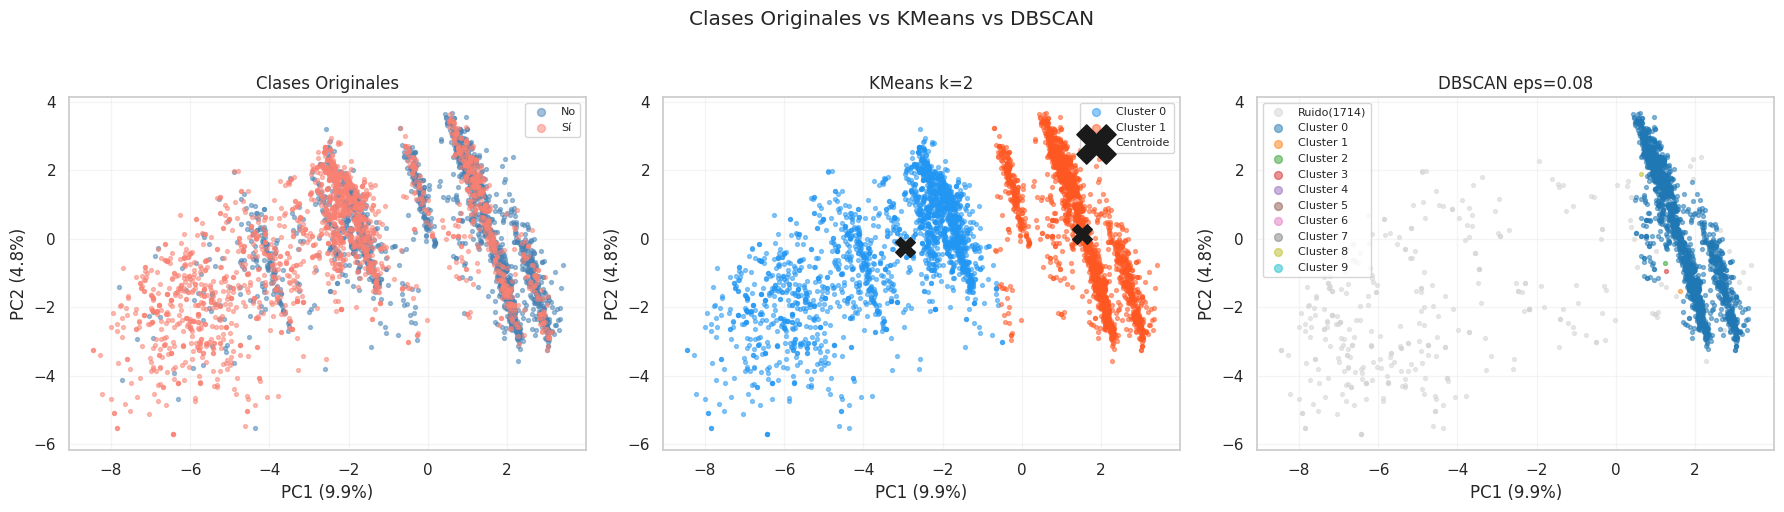

In [ ]:
import matplotlib.pyplot as plt

# 4 ── PLOTS
indices_muestra = np.concatenate([
    np.random.default_rng(21).choice(np.where(y_full == clase)[0], 2000)
    for clase in [0, 1]
])

fig, ejes = plt.subplots(1, 3, figsize=(18, 5))

# Original
for clase, color, etiqueta in [(0, 'steelblue', 'No'), (1, 'salmon', 'Sí')]:
    mascara = y_full.values[indices_muestra] == clase
    ejes[0].scatter(X_pca_2d[indices_muestra][mascara, 0],
                    X_pca_2d[indices_muestra][mascara, 1],
                    c=color, s=8, alpha=.5, label=etiqueta)

# KMeans
for cluster, color in [(0, '#2196F3'), (1, '#FF5722')]:
    mascara = modelo_kmeans.labels_[indices_muestra] == cluster
    ejes[1].scatter(X_pca_2d[indices_muestra][mascara, 0],
                    X_pca_2d[indices_muestra][mascara, 1],
                    c=color, s=8, alpha=.5, label=f'Cluster {cluster}')
ejes[1].scatter(*modelo_kmeans.cluster_centers_.T,
                c='k', s=200, marker='X', zorder=10, label='Centroide')

# DBSCAN
for cluster, color in [(-1, 'lightgray')] + list(enumerate(plt.cm.tab10.colors[:num_clusters])):
    mascara  = etiquetas_dbscan[indices_muestra] == cluster
    etiqueta = f'Ruido({num_ruido})' if cluster == -1 else f'Cluster {cluster}'
    ejes[2].scatter(X_pca_2d[indices_muestra][mascara, 0],
                    X_pca_2d[indices_muestra][mascara, 1],
                    c=[color], s=8, alpha=.5, label=etiqueta)

titulos = [
    'Clases Originales',
    'KMeans k=2',
    f'DBSCAN eps={valor_eps}'
]

for eje, titulo in zip(ejes, titulos):
    eje.set(title=titulo,
            xlabel=f'PC1 ({varianza_pc1:.1f}%)',
            ylabel=f'PC2 ({varianza_pc2:.1f}%)')
    eje.legend(markerscale=2, fontsize=8)
    eje.grid(alpha=.2)

plt.suptitle('Clases Originales vs KMeans vs DBSCAN', y=1.02)
plt.tight_layout()
plt.show()

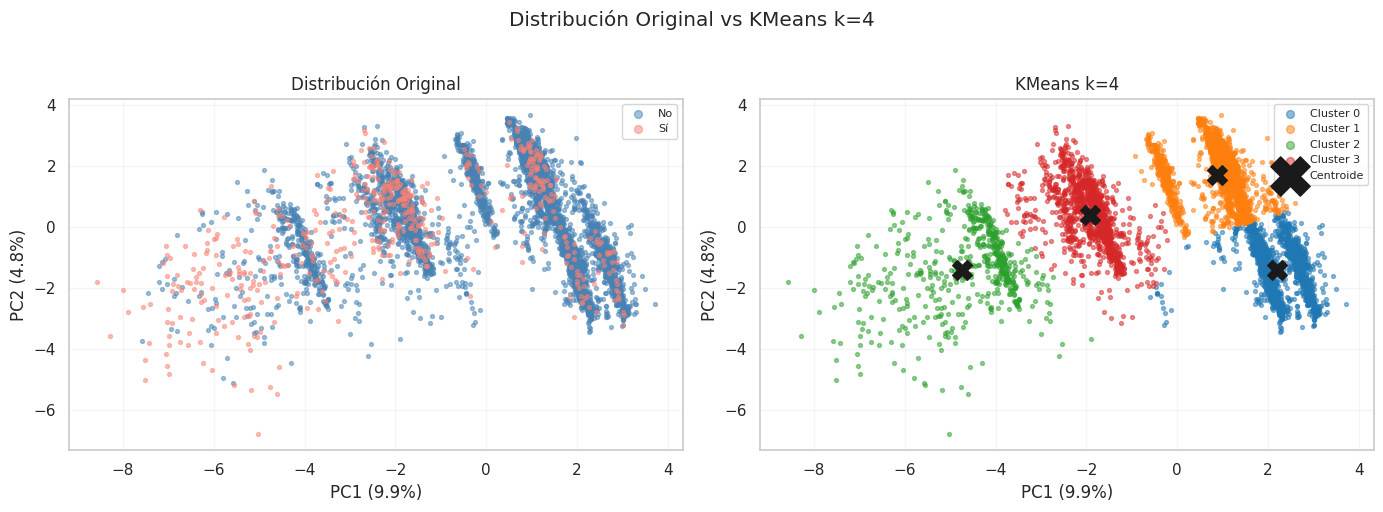

Distribución clusters: {0: np.int64(13506), 1: np.int64(13528), 2: np.int64(5028), 3: np.int64(9126)}


In [ ]:
modelo_kmeans_4 = KMeans(n_clusters=4, random_state=21, n_init=10).fit(X_pca_2d)
etiquetas_kmeans_4 = modelo_kmeans_4.labels_

# Subsample para graficar rápido
indices_muestra_4 = np.random.default_rng(21).choice(len(X_pca_2d), size=5000, replace=False)

fig, ejes = plt.subplots(1, 2, figsize=(14, 5))

# Distribución original
for clase, color, etiqueta in [(0, 'steelblue', 'No'), (1, 'salmon', 'Sí')]:
    mascara = y_full.values[indices_muestra_4] == clase
    ejes[0].scatter(X_pca_2d[indices_muestra_4][mascara, 0],
                    X_pca_2d[indices_muestra_4][mascara, 1],
                    c=color, s=8, alpha=.5, label=etiqueta)
ejes[0].set(title='Distribución Original', xlabel=f'PC1 ({varianza_pc1:.1f}%)', ylabel=f'PC2 ({varianza_pc2:.1f}%)')
ejes[0].legend(markerscale=2, fontsize=8); ejes[0].grid(alpha=.2)

# KMeans k=4
for cluster, color in enumerate(plt.cm.tab10.colors[:4]):
    mascara = etiquetas_kmeans_4[indices_muestra_4] == cluster
    ejes[1].scatter(X_pca_2d[indices_muestra_4][mascara, 0],
                    X_pca_2d[indices_muestra_4][mascara, 1],
                    c=[color], s=8, alpha=.5, label=f'Cluster {cluster}')
ejes[1].scatter(*modelo_kmeans_4.cluster_centers_.T,
                c='k', s=200, marker='X', zorder=10, label='Centroide')
ejes[1].set(title='KMeans k=4', xlabel=f'PC1 ({varianza_pc1:.1f}%)', ylabel=f'PC2 ({varianza_pc2:.1f}%)')
ejes[1].legend(markerscale=2, fontsize=8); ejes[1].grid(alpha=.2)

plt.suptitle('Distribución Original vs KMeans k=4', y=1.02)
plt.tight_layout()
plt.show()

print(f"Distribución clusters: { {c: (etiquetas_kmeans_4==c).sum() for c in range(4)} }")